# Hugging Face Text-to-Image — Stable Diffusion v1.5

Generate images from text with **[stable-diffusion-v1-5/stable-diffusion-v1-5](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5)** using the `diffusers` library.

On Apple Silicon the pipeline runs on **MPS**; otherwise CUDA or CPU.

## Load env (`HF_HOME`, `HF_TOKEN`)

Reads the repo-root `.env` (see `.env.example`). Weights download into `HF_HOME` on first run so other projects can reuse them.

In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

# Repo-root .env when the notebook cwd is the project subfolder
env_path = Path.cwd().parent / ".env"
if not env_path.is_file():
    env_path = Path.cwd() / ".env"
load_dotenv(env_path)

if "HF_HOME" in os.environ:
    os.environ["HF_HOME"] = os.path.expanduser(os.environ["HF_HOME"])

# importing the constants after setting the env var.
from huggingface_hub.constants import HF_HOME, HF_HUB_CACHE

print("HF_HOME:", HF_HOME)
print("hub cache:", HF_HUB_CACHE)

HF_HOME: /Users/riteshraj/ml-models
hub cache: /Users/riteshraj/ml-models/hub


## Load pipeline

Builds `StableDiffusionPipeline` from Hugging Face. First run downloads ~4 GB of weights into `HF_HOME`.

In [2]:
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

if torch.backends.mps.is_available():
    device = "mps"
    dtype = torch.float16
elif torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
else:
    device = "cpu"
    dtype = torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
)
pipe = pipe.to(device)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("device:", device, "| dtype:", dtype)

/Users/riteshraj/Documents/my-github/ml-dl-py/hf-text-to-image/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `CLIPImageProcessor` requires torchvision (not installed); falling back to `CLIPImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `CLIPImageProcessorPil` directly to silence this warning.
[transformers] `SiglipImageProcessor` requires torchvision (not installed); falling back to `SiglipImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `SiglipImageProcessorPil` directly to silence this warning.
/Users/riteshraj/Documents/my-github/ml-dl-py/hf-text-to-image/.venv/lib/python3.12/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is depr

device: mps | dtype: torch.float16


## Demo: human thinking — Book Illustration style

Generates a storybook-style illustration of a person deep in thought.

100%|██████████| 30/30 [00:32<00:00,  1.10s/it]


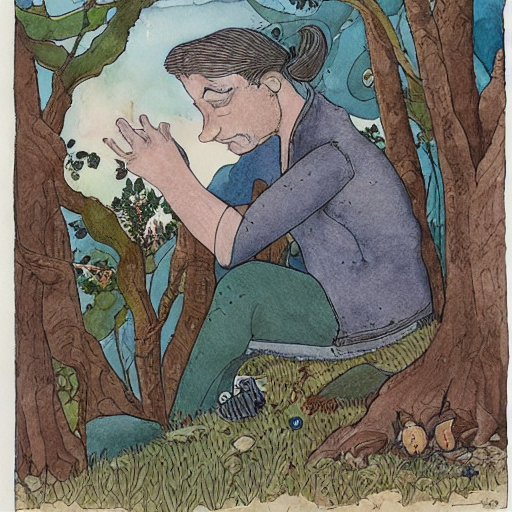

saved: output/human_thinking_book_illustration.png


In [3]:
prompt = (
    "A thoughtful human deep in thought, hand on chin, "
    "Book Illustration style, detailed ink and watercolor, storybook art"
)
negative_prompt = (
    "photo, photorealistic, blurry, low quality, deformed, watermark, text"
)

generator = torch.Generator(device=device).manual_seed(42)

result = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator,
)
image = result.images[0]

out_path = OUTPUT_DIR / "human_thinking_book_illustration.png"
image.save(out_path)
display(image)
print("saved:", out_path)

## Weekly Calendar Template

Flat 2D vector weekly schedule chart: seven columns with a yellow sun doodle in each.


100%|██████████| 30/30 [00:31<00:00,  1.05s/it]


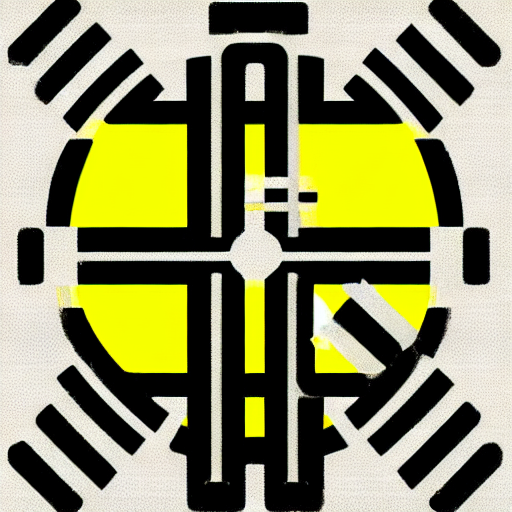

saved: output/weekly_calendar_template.png


In [8]:
custom_prompt = "A stark white background with a single thin black horizontal line across the center. Spaced along the line are seven tiny simple yellow circles. Flat 2D vector style, extreme minimalism, plain solid background, clip art icon layout, zero detail, clear composition"
custom_negative_prompt = "flower, mandala, intricate lines, swirls, trippy, patterns, shading, complexity, details, borders, frame, dark background, texture, realistic, sketch, drawing, lines everywhere"

result = pipe(
    custom_prompt,
    negative_prompt=custom_negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=torch.Generator(device=device).manual_seed(7),
)
custom_image = result.images[0]

custom_path = OUTPUT_DIR / "weekly_calendar_template.png"
custom_image.save(custom_path)
display(custom_image)
print("saved:", custom_path)
